# 07 — Adapter Blending

Interpolate two artist LoRA adapters in **delta space** to produce a continuum of
blended styles, then measure where the blend lands with the attribution classifier.

For a LoRA, the weight update is `ΔW = (α/r)·B·A`. We want

```
ΔW_blend(a) = a·ΔW_gojira + (1−a)·ΔW_tool
```

Averaging `A` and `B` separately is **wrong** (it adds cross-terms `B_g·A_t`).
The exact low-rank form is **rank concatenation** → a rank-`2r` adapter:

```
A_blend = [ a·A_gojira ; (1−a)·A_tool ]     # (2r, in)
B_blend = [ B_gojira , B_tool ]             # (out, 2r)
new config: r → 2r,  lora_alpha → 2·lora_alpha   (keeps scale α/r constant)
```

Endpoints recover the pure adapters (`a=1` zeroes the tool rows), which is the
built-in sanity check.

Building the blended adapters and validating them numerically is **CPU-only**.
Only the generation/eval section at the bottom needs the GPU.

In [1]:
from evaluation.blend import blend_adapters, materialize_delta
from config import ADAPTERS_DIR

ALPHAS = [0.0, 0.25, 0.5, 0.75, 1.0]   # 1 = pure Gojira, 0 = pure Tool
SRC_A, SRC_B = "gojira_lora_r8", "tool_lora_r8"

## 1. Blend builder (CPU)

In [2]:
blend_names = [blend_adapters(SRC_A, SRC_B, a) for a in ALPHAS]
blend_names

wrote artifacts/adapters/blend_gojira_tool_a0.00  (r=16, alpha=32, 516 tensors)
wrote artifacts/adapters/blend_gojira_tool_a0.25  (r=16, alpha=32, 516 tensors)
wrote artifacts/adapters/blend_gojira_tool_a0.50  (r=16, alpha=32, 516 tensors)
wrote artifacts/adapters/blend_gojira_tool_a0.75  (r=16, alpha=32, 516 tensors)
wrote artifacts/adapters/blend_gojira_tool_a1.00  (r=16, alpha=32, 516 tensors)


['blend_gojira_tool_a0.00',
 'blend_gojira_tool_a0.25',
 'blend_gojira_tool_a0.50',
 'blend_gojira_tool_a0.75',
 'blend_gojira_tool_a1.00']

## 2. Numerical validation (CPU)

Materialize `ΔW = (α/r)·B·A` for one layer from the pure adapters and from each
blend, and check `ΔW_blend ≈ a·ΔW_gojira + (1−a)·ΔW_tool` to floating-point
tolerance. No GPU, no base model needed.

In [3]:
PREFIX = "base_model.model.model.language_model.layers.0.mlp.gate_proj"
d_g = materialize_delta(SRC_A, PREFIX)
d_t = materialize_delta(SRC_B, PREFIX)

for a, name in zip(ALPHAS, blend_names):
    d_b = materialize_delta(name, PREFIX)
    expected = a * d_g + (1 - a) * d_t
    err = (d_b - expected).abs().max().item()
    print(f"alpha={a:.2f}  max|d_blend - (a*d_g + (1-a)*d_t)| = {err:.2e}")
    assert err < 1e-4, f"blend mismatch at alpha={a}"

print("\nall blends match delta-space interpolation")

alpha=0.00  max|d_blend - (a*d_g + (1-a)*d_t)| = 0.00e+00
alpha=0.25  max|d_blend - (a*d_g + (1-a)*d_t)| = 8.46e-07
alpha=0.50  max|d_blend - (a*d_g + (1-a)*d_t)| = 2.91e-11
alpha=0.75  max|d_blend - (a*d_g + (1-a)*d_t)| = 8.91e-07
alpha=1.00  max|d_blend - (a*d_g + (1-a)*d_t)| = 0.00e+00

all blends match delta-space interpolation


## 3. Attribution results  *(computed by `evaluate.py`)*

`run_blends` in `evaluate.py` builds each blend and scores it with the attribution
classifier, caching `results/blends/<pair>/a<alpha>.json`. Run
`uv run python evaluate.py` first, then this cell just reads the cache. Endpoints
(`a=0`, `a=1`) should match the pure-adapter numbers from `06_evaluation.ipynb`.

In [4]:
import json
import pandas as pd
from config import RESULTS_DIR

# Display-only: blends are built + scored by evaluate.py (run_blends).
# Run `uv run python evaluate.py` first.
BLENDS_DIR = RESULTS_DIR / "blends"
PAIR = f"{SRC_A.split('_')[0]}_{SRC_B.split('_')[0]}"   # gojira_tool

records, all_samples = [], {}
for a in ALPHAS:
    f = BLENDS_DIR / PAIR / f"a{a:.2f}.json"
    if not f.exists():
        print(f"missing alpha={a:.2f} -- run `uv run python evaluate.py`")
        continue
    hit = json.load(open(f))
    df = pd.DataFrame(hit["df"])
    all_samples[a] = hit["samples"]
    records.append({"alpha": a,
                    "Gojira": df["Gojira"].mean(), "Gojira_std": df["Gojira"].std(),
                    "Tool": df["Tool"].mean(),     "Tool_std": df["Tool"].std()})
    print(f"alpha={a:.2f}  Gojira={records[-1]['Gojira']:.3f}  Tool={records[-1]['Tool']:.3f}")

blend_df = pd.DataFrame(records)
blend_df

alpha=0.00  Gojira=0.071  Tool=0.809
alpha=0.25  Gojira=0.559  Tool=0.212
alpha=0.50  Gojira=0.904  Tool=0.041
alpha=0.75  Gojira=0.882  Tool=0.006
alpha=1.00  Gojira=0.961  Tool=0.006


,alpha,Gojira,Gojira_std,Tool,Tool_std
0,0.00,0.070689,0.171332,0.808777,0.329092
1,0.25,0.558539,0.387124,0.212193,0.303802
2,0.50,0.903598,0.144491,0.040901,0.103875
3,0.75,0.881737,0.308079,0.006067,0.006658
4,1.00,0.961233,0.068613,0.006254,0.004640


## 4. Interpolation figure

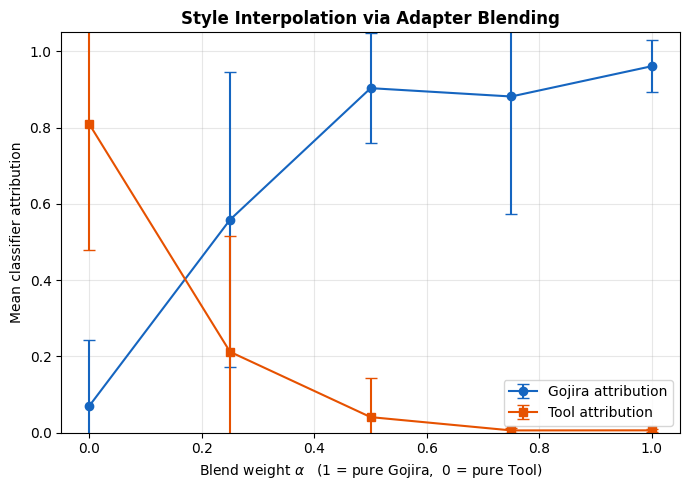

In [5]:
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["pdf.fonttype"] = 42

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(blend_df["alpha"], blend_df["Gojira"], yerr=blend_df["Gojira_std"],
            marker="o", capsize=4, color="#1565c0", label="Gojira attribution")
ax.errorbar(blend_df["alpha"], blend_df["Tool"], yerr=blend_df["Tool_std"],
            marker="s", capsize=4, color="#e65100", label="Tool attribution")
ax.set_xlabel(r"Blend weight $\alpha$   (1 = pure Gojira,  0 = pure Tool)")
ax.set_ylabel("Mean classifier attribution")
ax.set_title("Style Interpolation via Adapter Blending", fontweight="bold")
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig("../report/figures/blending_interpolation.pdf", bbox_inches="tight", dpi=300)
plt.show()